In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [12]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


In [13]:
X_train = X_train[:8000].reshape(8000,3072)
y_train = y_train[:8000].flatten()

X_test = X_test[:500].reshape(500,3072)
y_test = y_test[:500].flatten()

In [14]:
def distance(a, b, metric):
    if metric == 'euclidean':
        return np.sqrt(np.sum((a - b) ** 2))
    if metric == 'manhattan':
        return np.sum(np.abs(a - b))
    if metric == 'minkowski':
        return np.sum(np.abs(a - b) ** 3) ** (1/3)
    if metric == 'cosine':
        return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)
    if metric == 'hamming':
        return np.mean(a != b)

In [15]:
def knn(k, metric):
    predictions = []
    for test in X_test:
        distances = []
        for train in X_train:
            distances.append(distance(test, train, metric))
        nearest = np.argsort(distances)[:k]
        count = [0] * 10
        for i in nearest:
            count[y_train[i]] += 1
        predictions.append(count.index(max(count)))
    return np.array(predictions)

In [16]:
k_values = [3,4,9,20,47]
metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine', 'hamming']

best_acc = 0
best_k = 1
best_metric = ''
best_pred = None

results = {}

for metric in metrics:
    acc_list = []

    for k in k_values:
        pred = knn(k, metric)
        acc = np.mean(pred == y_test)
        acc_list.append(acc)

        print(metric, 'K =', k, 'Accuracy =', round(acc, 3))

        if acc > best_acc:
            best_acc = acc
            best_k = k
            best_metric = metric
            best_pred = pred

    results[metric] = acc_list

print('\\nBest K =', best_k)
print('Best Distance Metric =', best_metric)
print('Best Accuracy =', round(best_acc, 3))


euclidean K = 3 Accuracy = 0.192
euclidean K = 4 Accuracy = 0.194
euclidean K = 9 Accuracy = 0.224
euclidean K = 20 Accuracy = 0.23
euclidean K = 47 Accuracy = 0.234
manhattan K = 3 Accuracy = 0.252
manhattan K = 4 Accuracy = 0.252
manhattan K = 9 Accuracy = 0.278
manhattan K = 20 Accuracy = 0.268
manhattan K = 47 Accuracy = 0.26
minkowski K = 3 Accuracy = 0.116
minkowski K = 4 Accuracy = 0.122
minkowski K = 9 Accuracy = 0.134
minkowski K = 20 Accuracy = 0.136
minkowski K = 47 Accuracy = 0.128
cosine K = 3 Accuracy = 0.096
cosine K = 4 Accuracy = 0.094
cosine K = 9 Accuracy = 0.12
cosine K = 20 Accuracy = 0.116
cosine K = 47 Accuracy = 0.102
hamming K = 3 Accuracy = 0.208
hamming K = 4 Accuracy = 0.228
hamming K = 9 Accuracy = 0.264
hamming K = 20 Accuracy = 0.254
hamming K = 47 Accuracy = 0.246
\nBest K = 9
Best Distance Metric = manhattan
Best Accuracy = 0.278


In [17]:
# Best K
# Re-derive best_k and best_metric from results dictionary
derived_best_acc = 0
derived_best_k = 0
derived_best_metric = ''

for metric_name, accuracies_list in results.items():
    for i, acc in enumerate(accuracies_list):
        if acc > derived_best_acc:
            derived_best_acc = acc
            derived_best_k = k_values[i]
            derived_best_metric = metric_name

best_pred = knn(derived_best_k, derived_best_metric)
print('\nBest K =', derived_best_k)
print('Best Distance Metric =', derived_best_metric)
print('Best Accuracy =', round(derived_best_acc, 3))


Best K = 9
Best Distance Metric = manhattan
Best Accuracy = 0.278


In [18]:
cm = np.zeros((10,10), dtype=int)

for t, p in zip(y_test, best_pred):
    cm[t][p] += 1

print('\\nConfusion Matrix')
print(cm)


\nConfusion Matrix
[[35  0  7  1  4  0  2  1  7  0]
 [13  3  8  5  7  0  1  0  2  2]
 [14  0 22  4  5  0  4  1  1  0]
 [ 2  0 22  5  8  1  8  0  2  1]
 [11  2  8  2 12  0  3  2  0  0]
 [ 7  1 12  2  8  6  7  3  2  0]
 [11  0 15  3  3  1 20  1  0  0]
 [10  1  5  5 10  1  5  6  3  1]
 [17  1  4  2  4  1  1  0 26  1]
 [22  5  9  5  1  2  1  0  7  4]]


In [19]:
precision = []
recall = []

for i in range(10):
    tp = cm[i][i]
    fp = np.sum(cm[:,i]) - tp
    fn = np.sum(cm[i,:]) - tp

    if tp + fp == 0:
        precision.append(0)
    else:
        precision.append(tp/(tp+fp))

    if tp + fn == 0:
        recall.append(0)
    else:
        recall.append(tp/(tp+fn))

print('\\nPrecision')
print(np.round(precision,2))

print('\\nRecall')
print(np.round(recall,2))

\nPrecision
[0.25 0.23 0.2  0.15 0.19 0.5  0.38 0.43 0.52 0.44]
\nRecall
[0.61 0.07 0.43 0.1  0.3  0.12 0.37 0.13 0.46 0.07]


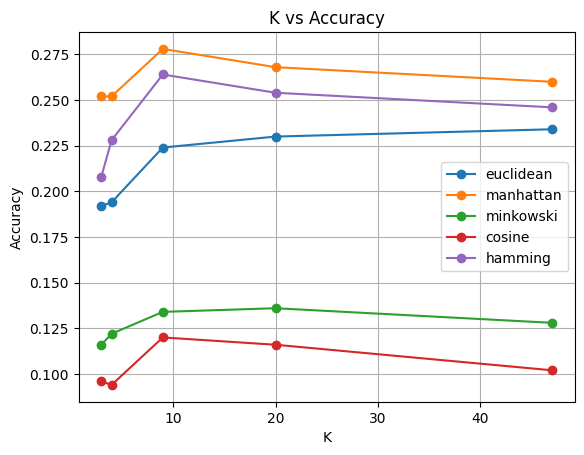

In [20]:
# ---------- Graph ----------
for metric in metrics:
    plt.plot(k_values, results[metric], marker='o', label=metric)

plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()